# Parts 2–3 walkthrough — reference, simulation, Longstaff–Schwartz

| module | role |
|---|---|
| `reference.py` | single entry point for the reference: the **supplied** `reference_results.npz` (our solver as cross-check) |
| `part2_supplied_verify.py` | runs the supplied `reference_solver.py --verify` and the cross-check |
| `part2_reference_check.py` | refinement study (spatial / time / domain) vs changing $N$ |
| `simulation.py` | exact paths, training mixture $A$, seeded path sets (README draw order and arithmetic) |
| `lsm.py` | LS regression → threshold → cap, replay check |
| `evaluate.py` | frozen-policy prices, boundary errors, ordering diagnostics |

In [1]:
import numpy as np, pandas as pd
pd.set_option("display.width", 160)
import config as cfg, simulation as sim, lsm, evaluate as ev, part2_reference_check as p2
from reference import load_reference
from IPython.display import Image

## Step 0 — The supplied reference passes `--verify`

The supplied solver is run unchanged. Our independent solver agrees with its arrays to within the refinement changes.

In [2]:
display(pd.read_csv("tables/p2_supplied_verify.csv")); display(pd.read_csv("tables/p2_own_vs_supplied.csv"))

,case_key,N,delta,spatial_dV_max,spatial_db_max,spatial_db_median,temporal_dV_max,temporal_db_max,temporal_db_median,db_max_time,saved_price_max_diff,saved_boundary_max_diff
0,N180_d0,180,0.0000,0.000016,0.001560,0.000223,0.000018,0.001465,0.000183,0.745833,2.123635e-12,9.904966e-12
1,N180_d0125,180,0.0125,0.000014,0.001560,0.000088,0.000015,0.001465,0.000026,0.745833,2.636114e-12,1.162164e-10
2,N360_d0,360,0.0000,0.000016,0.001846,0.000366,0.000010,0.001477,0.000133,0.747917,3.186784e-12,2.235367e-11
3,N360_d0125,360,0.0125,0.000013,0.001846,0.000189,0.000008,0.001477,0.000013,0.747917,4.087397e-12,1.616911e-10


,case_key,N,delta,V_supplied(60),V_supplied(80),V_supplied(100),dV_max,db_max,db_median,db_max_j
0,N180_d0,180,0.0000,40.0,20.868793,8.807841,0.000008,0.000738,0.000099,179
1,N180_d0125,180,0.0125,40.0,22.109551,10.126405,0.000004,0.000738,0.000027,179
2,N360_d0,360,0.0000,40.0,20.870990,8.809143,0.000007,0.001088,0.000120,359
3,N360_d0125,360,0.0125,40.0,22.110207,10.126965,0.000006,0.001088,0.000056,359


## Step 1 — Supplementary: the same refinement study on our own solver

**Design.** Change one numerical setting at a time and record the largest price change and the largest boundary change. The same table shows the effect of going from $N=180$ to $360$, which is a different problem rather than a refinement.

In [3]:
display(p2.refinement_table()[["N","delta","refinement","dV_spots","db"]])
display(p2.n_change_table())

,N,delta,refinement,dV_spots,db
0,180,0.0000,spatial dx/2,1.051821e-05,1.079353e-03
1,180,0.0000,spatial dx/4,1.328388e-05,1.020396e-03
2,180,0.0000,time h/2 (substeps=2),1.207647e-09,1.419807e-07
3,180,0.0000,time h/4 (substeps=4),3.462635e-09,4.259877e-07
4,180,0.0000,domain wider,0.000000e+00,0.000000e+00
5,180,0.0000,kernel tails n_sd=14,0.000000e+00,2.984279e-13
6,180,0.0125,spatial dx/2,1.195648e-05,1.079353e-03
7,180,0.0125,spatial dx/4,1.524521e-05,1.020396e-03
8,180,0.0125,time h/2 (substeps=2),9.750867e-10,1.419807e-07
9,180,0.0125,time h/4 (substeps=4),2.708518e-09,4.259877e-07


,delta,dV(60),dV(80),dV(100),min_dV_grid,max_db,mean_db,source
0,0.0000,0.0,0.002197,0.001302,0.0,0.306161,-0.256124,supplied
1,0.0125,0.0,0.000657,0.000560,0.0,0.306161,-0.078348,supplied


**Reading.**
* Supplied reference: spatial and time refinements change prices by about $2\times10^{-5}$ \$ and boundaries by about $2\times10^{-3}$ \$ (Step 0).
* Our own solver behaves similarly. Its time refinement is essentially zero, because its kernel integrates the lognormal step exactly.
* Changing $N$ (supplied arrays) changes prices by about $2\times10^{-3}$ \$ and boundaries by about $0.3$ \$: a different problem.
* So any accuracy claim smaller than about $2\times10^{-5}$ \$ cannot be resolved against the reference.

## Step 2 — Exact simulation and the martingale check

Under $Q$, $E[S_T]=S_0e^{rT}(1-\delta)^3$. We check it on the final $S_0=100$ evaluation sample and report $z$ = (difference)/SE.

In [4]:
display(pd.DataFrame([sim.martingale_check(c) for c in range(4)]))
rng = np.random.default_rng(0); A = sim.sample_A(rng, 200_000) / cfg.K
print("P(A/K < 0.2) =", (A < 0.2).mean(), " theory:", 0.5*np.log(200)/np.log(1000))

,case,N,delta,mean_ST,theory,diff,se,z
0,0,180,0.0000,103.741356,103.727037,0.014318,0.122044,0.117320
1,1,180,0.0125,99.959089,99.885693,0.073396,0.117701,0.623577
2,2,360,0.0000,103.967531,103.727037,0.240494,0.122395,1.964898
3,3,360,0.0125,99.912295,99.885693,0.026602,0.117849,0.225726


P(A/K < 0.2) = 0.38505  theory: 0.38350499927733017


## Step 3 — Fit LS on each case

**Checks.**
* The fallback, multiple-crossing and capped-date counts.
* The **replay** check: forward application of the frozen rule must reproduce the backward targets exactly.

In [5]:
ls = {}
for c in range(4):
    tg, S = sim.training_paths_LS(c)
    ls[c] = lsm.fit_ls(S, tg, sim.CASES[c][1])
    r = ls[c]
    print(c, sim.CASES[c], "fallbacks", len(r.fallback), "| multi-crossing", len(r.multi_cross_dates),
          "| capped", len(r.capped_dates), "| replay max|Q-Y|", r.replay_max_abs_diff)

0 (180, 0.0) fallbacks 0 | multi-crossing 176 | capped 0 | replay max|Q-Y| 0.0


1 (180, 0.0125) fallbacks 0 | multi-crossing 138 | capped 83 | replay max|Q-Y| 0.0


2 (360, 0.0) fallbacks 0 | multi-crossing 360 | capped 0 | replay max|Q-Y| 0.0


3 (360, 0.0125) fallbacks 0 | multi-crossing 273 | capped 154 | replay max|Q-Y| 0.0


## Step 4 — Why two crossings?

The cubic is fitted over $x\in[0.001,1]$. As a result, $H$ dips below zero near $s\approx3$ and turns positive again before the true boundary. The largest-crossing rule keeps the economically correct single exercise interval.

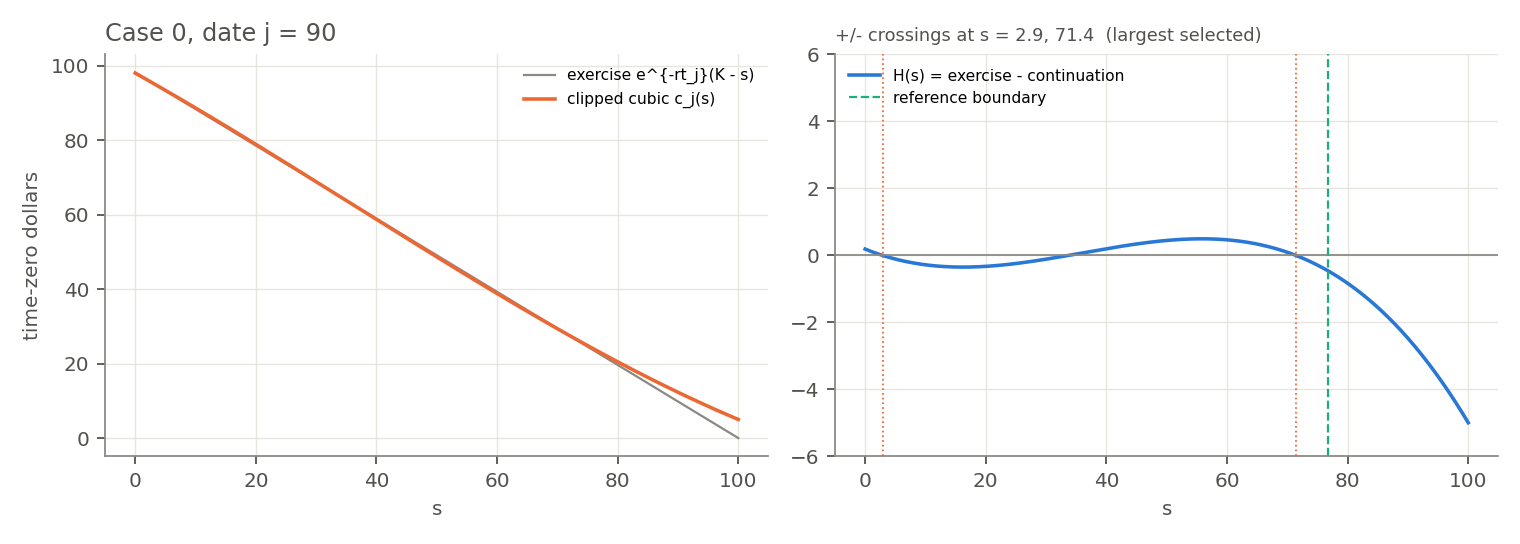

In [6]:
Image("figures/p23_H_example.png")

## Step 5 — Boundaries and prices (Part 5 preview for LS)

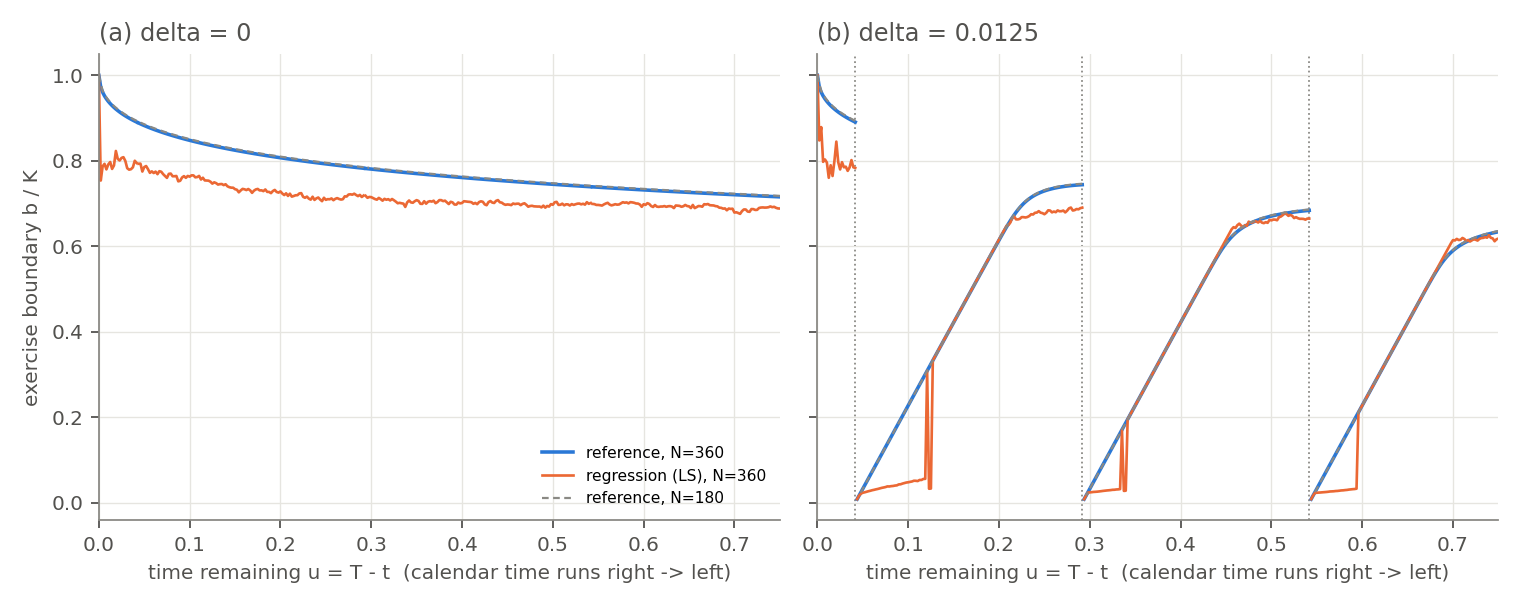

In [7]:
Image("figures/p23_boundaries_ls_ref.png")

In [8]:
display(pd.read_csv("tables/p5_prices.csv"))
display(pd.read_csv("tables/p5_paired.csv"))
display(pd.read_csv("tables/p5_boundary_errors.csv"))
display(pd.read_csv("tables/p1_ordering_checks.csv"))

,case,N,delta,method,S0,mean,se,lo,hi,ref_value,z_vs_ref
0,0,180,0.0000,LS,60.0,40.000000,0.000000,40.000000,40.000000,40.000000,NaN
1,0,180,0.0000,NN,60.0,40.000000,0.000000,40.000000,40.000000,40.000000,NaN
2,0,180,0.0000,ref-boundary policy,60.0,40.000000,0.000000,40.000000,40.000000,40.000000,NaN
3,0,180,0.0000,LS,80.0,20.661120,0.055753,20.551845,20.770395,20.868793,-3.724887
4,0,180,0.0000,NN,80.0,20.632064,0.056300,20.521717,20.742411,20.868793,-4.204805
5,0,180,0.0000,ref-boundary policy,80.0,20.843846,0.044744,20.756147,20.931544,20.868793,-0.557545
6,0,180,0.0000,LS,100.0,8.639783,0.049986,8.541810,8.737757,8.807841,-3.362058
7,0,180,0.0000,NN,100.0,8.623239,0.050127,8.524990,8.721488,8.807841,-3.682669
8,0,180,0.0000,ref-boundary policy,100.0,8.773429,0.044760,8.685700,8.861158,8.807841,-0.768801
9,1,180,0.0125,LS,60.0,40.000000,0.000000,40.000000,40.000000,40.000000,NaN


,case,pair,S0,mean_diff,se
0,0,LS - NN,60.0,0.000000,0.000000
1,0,LS - ref-boundary policy,60.0,0.000000,0.000000
2,0,NN - ref-boundary policy,60.0,0.000000,0.000000
3,0,LS - NN,80.0,0.029056,0.010236
4,0,LS - ref-boundary policy,80.0,-0.182726,0.033699
5,0,NN - ref-boundary policy,80.0,-0.211782,0.034668
6,0,LS - NN,100.0,0.016544,0.006320
7,0,LS - ref-boundary policy,100.0,-0.133646,0.023399
8,0,NN - ref-boundary policy,100.0,-0.150190,0.023847
9,1,LS - NN,60.0,0.000000,0.000000


,case,N,delta,method,E_mean,E_max,j_at_max
0,0,180,0.0000,LS,0.068712,0.203524,177
1,0,180,0.0000,NN,0.071753,0.222223,179
2,1,180,0.0125,LS,0.033892,0.237071,152
3,1,180,0.0125,NN,0.017418,0.155077,170
4,2,360,0.0000,LS,0.063876,0.218541,359
5,2,360,0.0000,NN,0.061941,0.219736,359
6,3,360,0.0125,LS,0.037156,0.291560,300
7,3,360,0.0125,NN,0.042552,0.172694,296


,N,method,A,B,F
0,180,LS,0.0,0.000000,0.066405
1,180,NN,21.0,0.051476,0.081677
2,180,ref,0.0,0.000000,0.000000
3,180,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000
4,360,LS,0.0,0.000000,0.093846
5,360,NN,36.0,0.051213,0.171841
6,360,ref,0.0,0.000000,0.000000
7,360,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000


**Reading.**
* LS boundary errors are several percent of $K$, yet the paired price loss against the reference rule is only about 0.02–0.25 \$. The value is flat near the optimal threshold, so price error is roughly second order in boundary error.
* LS respects the ordering before $d_3$ ($A=0$). The nonzero $F$ after $d_3$ is regression and sampling noise between two independently trained fits.